In [20]:
# Pareto principle demonstration

import pandas as pd
import random

complaints = ['Room Cleanliness', 'Service', 'Food', 'Wi-Fi', 'Noise', 'Other']
data = {
    'Guest_ID': range(1, 101),
    'Complaint': [random.choices(complaints, weights=[30,25,20,10,10,5])[0] for _ in range(100)]
}
df = pd.DataFrame(data)
df.head()

,Guest_ID,Complaint
0,1,Service
1,2,Room Cleanliness
2,3,Room Cleanliness
3,4,Food
4,5,Service


In [21]:
complaint_counts = df['Complaint'].value_counts().reset_index()
complaint_counts.columns = ['Complaint', 'Count']
complaint_counts

,Complaint,Count
0,Room Cleanliness,29
1,Service,26
2,Food,26
3,Noise,10
4,Wi-Fi,6
5,Other,3


In [22]:
# Sort by count descending
complaint_counts = complaint_counts.sort_values(by='Count', ascending=False)

# Calculate cumulative sum and percentage
complaint_counts['Cumulative_Count'] = complaint_counts['Count'].cumsum()
complaint_counts['Cumulative_Percentage'] = 100 * complaint_counts['Cumulative_Count'] / complaint_counts['Count'].sum()

# Identify complaints causing 80% of issues
top_complaints = complaint_counts[complaint_counts['Cumulative_Percentage'] <= 80]

print(top_complaints)

          Complaint  Count  Cumulative_Count  Cumulative_Percentage
0  Room Cleanliness     29                29                   29.0
1           Service     26                55                   55.0


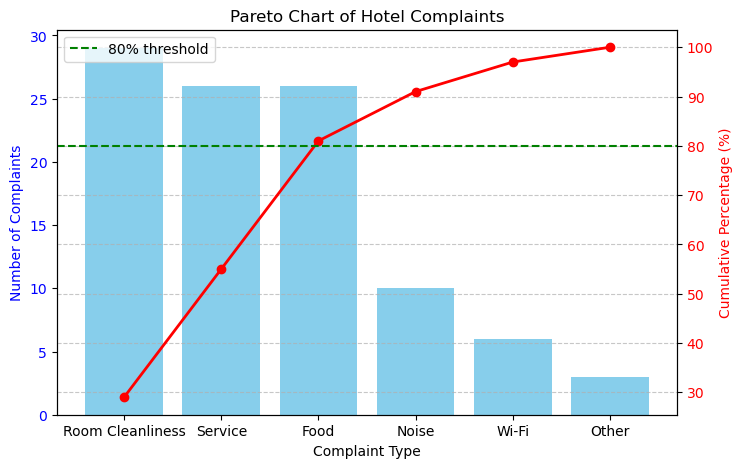

In [23]:
import matplotlib.pyplot as plt

# Pareto chart
fig, ax1 = plt.subplots(figsize=(8,5))

# Bar chart for complaint counts
ax1.bar(complaint_counts['Complaint'], complaint_counts['Count'], color='skyblue')
ax1.set_xlabel('Complaint Type')
ax1.set_ylabel('Number of Complaints', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Line chart for cumulative percentage
ax2 = ax1.twinx()
ax2.plot(complaint_counts['Complaint'], complaint_counts['Cumulative_Percentage'], color='red', marker='o', linestyle='-', linewidth=2)
ax2.set_ylabel('Cumulative Percentage (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.axhline(80, color='green', linestyle='--', label='80% threshold')

# Title and grid
plt.title('Pareto Chart of Hotel Complaints')
plt.grid(axis='y', linestyle='--', alpha=0.7)
ax2.legend(loc='upper left')

plt.show()